# 3.0 — Deep Learning Storytelling: Knee X-ray Severity Grading

Stakeholder-facing views of the deep learning work: classifying knee X-rays into the five
**Kellgren–Lawrence (KL) osteoarthritis grades** (0 = healthy → 4 = severe), developed over
three measured iterations (v1 → v3).

**Numbers are transcribed from the measured runs documented in [`conclusion.md`](./conclusion.md)**
and the class counts are verified against the `data/` folders. If a model version is re-run,
update the values in the figure cells.

**Colour grammar** (same as the PROMs storytelling views — a business reader learns it once):

| Colour | Meaning |
|--------|---------|
| ⬛ Dark grey | Emphasis — the point of the chart |
| ⬜ Grey | Context |
| Pale | De-emphasised / uncertain |

The story in four figures:

1. **Figure A — the challenge**: the data is imbalanced, ordered, and ambiguous → accuracy is the wrong yardstick
2. **Figure B — the journey**: model consistency (QWK) per version vs how often radiologists agree with each other
3. **Figure C — the hardest grade**: Grade 1 "doubtful", from near-random to credible
4. **Figure D — what's next**: where the remaining improvement lives

In [1]:
import matplotlib.pyplot as plt

# ── Consistent visual style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        120,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "font.size":         11,
})

# ── Colour grammar: emphasis by darkness, not hue ────────────────────────────
GREY        = "#BDBDBD"   # context
PALE        = "#E0E0E0"   # de-emphasised / uncertain
ACCENT      = "#5C5C5C"   # emphasis
ACCENT_TEXT = "#212121"

print("Style loaded.")

Style loaded.


### Completing the Clinical Picture — From What Patients Report to What X-rays Show

The primary goal of this project is the PROMs no-benefit model — predicting outcomes from **what the patient reports**. This deep learning track was additional work to complement it with **what the X-ray shows**: an objective, consistent severity grade that supports clinicians in making better knee-care decisions. For audiences that only need the headline, this one figure carries the whole story:

- **The task**: grade knee X-rays into five *ordered* Kellgren–Lawrence severity grades — so
  ambiguous that radiologist pairs only agree at κ ≈ 0.65–0.75
- **The journey**: three measured iterations took the model to QWK 0.838 — above radiologist-pair
  agreement and inside the published model range (0.80–0.86)
- **The plateau**: v3 matched v2 to within noise — the dataset's ambiguity floor; tuning is exhausted
- **The next step**: crop the X-ray to the knee joint, projected to reach QWK 0.87–0.88

The detailed four-figure version follows below.

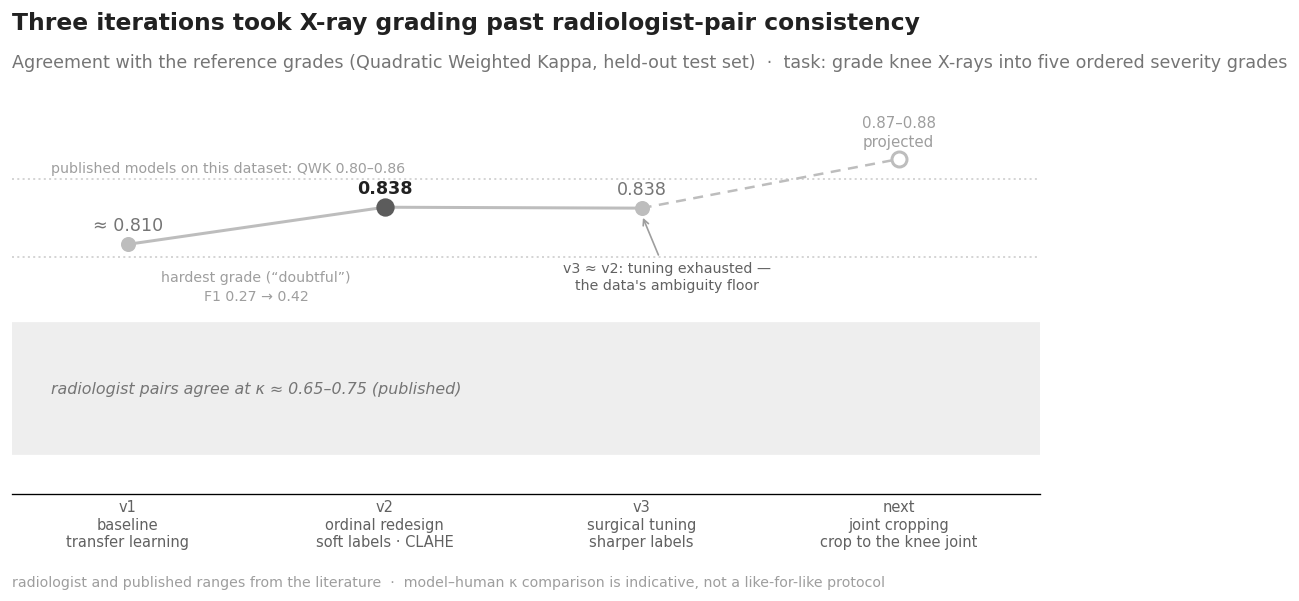

In [12]:
# ── The whole deep learning story in one figure ───────────────────────────────
# Measured QWK (held-out test set, TTA) from conclusion.md
VERSIONS = [
    ("v1\nbaseline\ntransfer learning",        0.810),   # approximate
    ("v2\nordinal redesign\nsoft labels · CLAHE", 0.8383),
    ("v3\nsurgical tuning\nsharper labels",   0.8376),
]
NEXT_LABEL = "next\njoint cropping\ncrop to the knee joint"
NEXT_QWK   = 0.875   # midpoint of the projected 0.87–0.88

xs   = list(range(len(VERSIONS)))
qwks = [q for _, q in VERSIONS]

fig, ax = plt.subplots(figsize=(11, 5.4))

# Reference 1: how often radiologists agree with each other
ax.axhspan(0.65, 0.75, color="#EEEEEE", zorder=1)
ax.text(-0.3, 0.70, "radiologist pairs agree at κ ≈ 0.65–0.75 (published)",
        ha="left", va="center", fontsize=9.5, color="#757575", style="italic")

# Reference 2: the published model range on this dataset
for y in (0.80, 0.86):
    ax.axhline(y, color="#D5D5D5", linestyle=":", linewidth=1.2, zorder=1)
ax.text(-0.3, 0.863, "published models on this dataset: QWK 0.80–0.86",
        ha="left", va="bottom", fontsize=8.5, color="#9E9E9E")

# The measured journey — v2 is the breakthrough
ax.plot(xs, qwks, color=GREY, linewidth=1.8, zorder=3)
for x, q in zip(xs, qwks):
    is_breakthrough = x == 1
    ax.plot(x, q, "o", markersize=10 if is_breakthrough else 8,
            color=ACCENT if is_breakthrough else GREY, zorder=4)
    approx = "≈ " if x == 0 else ""
    ax.text(x, q + 0.008, f"{approx}{q:.3f}", ha="center", va="bottom",
            fontsize=10.5, fontweight="bold" if is_breakthrough else "normal",
            color=ACCENT_TEXT if is_breakthrough else "#757575")

# The scoped next step — projected, so pale and dashed
ax.plot([2, 3], [qwks[2], NEXT_QWK], color=GREY, linewidth=1.5,
        linestyle=(0, (4, 3)), zorder=2)
ax.plot(3, NEXT_QWK, "o", markersize=9, markerfacecolor="white",
        markeredgecolor=GREY, markeredgewidth=1.8, zorder=4)
ax.text(3, NEXT_QWK + 0.008, "0.87–0.88\nprojected", ha="center", va="bottom",
        fontsize=9, color="#9E9E9E", linespacing=1.3)

# Story beats as annotations
ax.text(0.5, 0.778, "hardest grade (\u201cdoubtful\u201d)\nF1 0.27 → 0.42",
        ha="center", va="center", fontsize=8.5, color="#9E9E9E", linespacing=1.4)
ax.annotate("v3 ≈ v2: tuning exhausted —\nthe data's ambiguity floor",
            xy=(2, 0.8376 - 0.005), xytext=(2.1, 0.797), fontsize=8.5,
            ha="center", va="top", color="#616161",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.0))

ax.set_xticks(xs + [3])
ax.set_xticklabels([name for name, _ in VERSIONS] + [NEXT_LABEL],
                   fontsize=8.8, color="#616161")

# Headline = the takeaway
ax.text(0, 1.13, "Three iterations took X-ray grading past radiologist-pair consistency",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.04, "Agreement with the reference grades (Quadratic Weighted Kappa, held-out "
                 "test set)  ·  task: grade knee X-rays into five ordered severity grades",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.20, "radiologist and "
                  "published ranges from the literature  ·  model–human κ comparison is "
                  "indicative, not a like-for-like protocol",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_xlim(-0.45, 3.55)
ax.set_ylim(0.62, 0.93)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Figure A — The Challenge: Imbalanced, Ordered, Ambiguous

Three properties of the data shape every later decision:

- **Imbalanced** — 40% of X-rays are healthy; the severe grade has only 173 training images (13:1 ratio)
- **Ordered** — grades have an order, so predicting "severe" for a healthy knee is far worse than predicting "doubtful"
- **Ambiguous** — published agreement between expert radiologists is only κ ≈ 0.65–0.75; even humans disagree on ~3 in 10 cases

Together these rule out plain accuracy as the success measure and motivate **Quadratic Weighted Kappa (QWK)** —
the same statistic used to score agreement between radiologists, which punishes errors by the square of their distance.

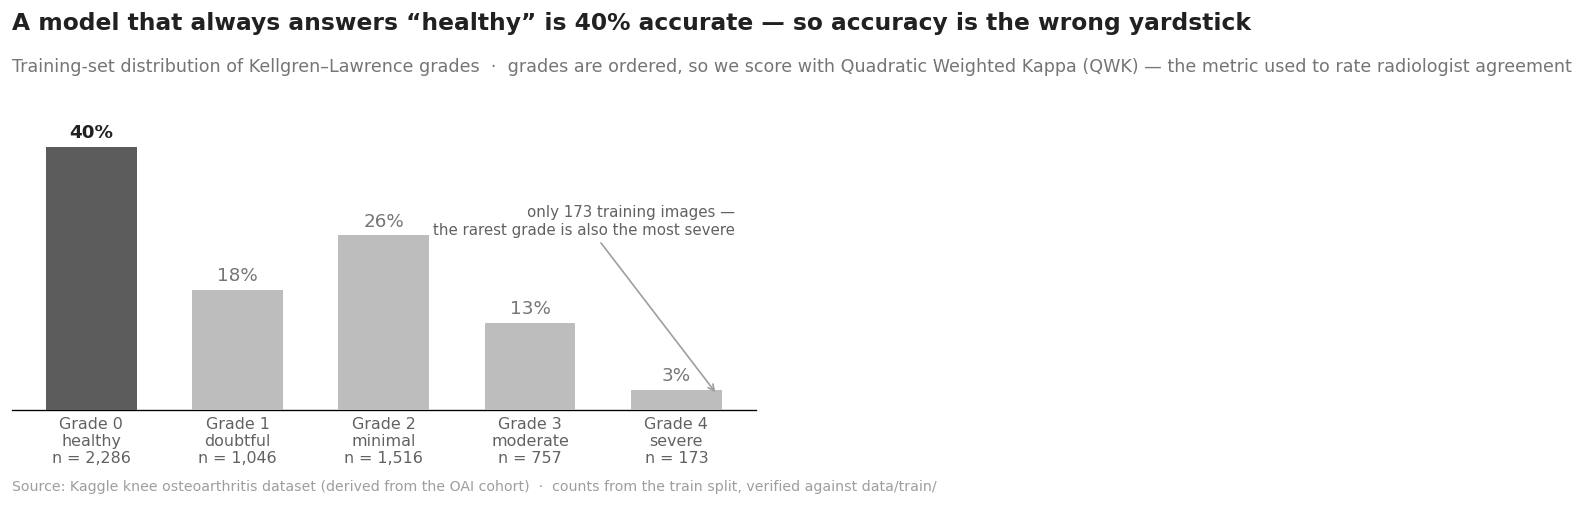

In [8]:
# ── Figure A: the deck is stacked — accuracy is the wrong yardstick ──────────
# Class counts verified against data/train/ folders
GRADES = [
    ("Grade 0", "healthy",  2286),
    ("Grade 1", "doubtful", 1046),
    ("Grade 2", "minimal",  1516),
    ("Grade 3", "moderate",  757),
    ("Grade 4", "severe",    173),
]
total = sum(n for _, _, n in GRADES)

fig, ax = plt.subplots(figsize=(11, 4.8))

for i, (grade, desc, n) in enumerate(GRADES):
    pct = 100 * n / total
    emphasised = i == 0   # the 40% majority drives the headline
    ax.bar(i, pct, color=ACCENT if emphasised else GREY, width=0.62, zorder=3)
    ax.text(i, pct + 0.8, f"{pct:.0f}%", ha="center", va="bottom", fontsize=11,
            fontweight="bold" if emphasised else "normal",
            color=ACCENT_TEXT if emphasised else "#757575")

ax.annotate("only 173 training images —\nthe rarest grade is also the most severe",
            xy=(4.28, 2.3), xytext=(4.4, 26), fontsize=9, ha="right", va="bottom", color="#616161",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.0))

ax.set_xticks(range(len(GRADES)))
ax.set_xticklabels([f"{g}\n{d}\nn = {n:,}" for g, d, n in GRADES],
                   fontsize=9.5, color="#616161")

# Headline = the takeaway, subtitle = how to read the chart
ax.text(0, 1.20, "A model that always answers \u201chealthy\u201d is 40% accurate — "
                 "so accuracy is the wrong yardstick",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.07, "Training-set distribution of Kellgren–Lawrence grades  ·  grades are ordered, "
                 "so we score with Quadratic Weighted Kappa (QWK) — the metric used to rate "
                 "radiologist agreement",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.22, "Source: Kaggle knee osteoarthritis dataset (derived from the OAI cohort)  ·  "
                  "counts from the train split, verified against data/train/",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_ylim(0, 47)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Figure B — The Journey: Three Versions, One Plateau

Each version was driven by a *diagnosed* weakness in the previous run, not by guesswork:

| Version | What changed | Why |
|---|---|---|
| v1 — baseline | Transfer learning (EfficientNet) + class-weighted loss | Get a measured starting point |
| v2 — ordinal redesign | Ordinal soft labels · CLAHE X-ray preprocessing · class-balanced sampling · QWK-based stopping | v1 ignored the grade ordering and starved the rare grades |
| v3 — surgical tuning | Sharper soft labels (σ 0.65→0.5) · stronger regularisation | v2 leaked Grade 2 cases into Grade 1 |

v3 matched v2 to within noise — the model reached the dataset's intrinsic ambiguity floor.
That **plateau is a finding**: more tuning cannot help; better inputs can (Figure D).

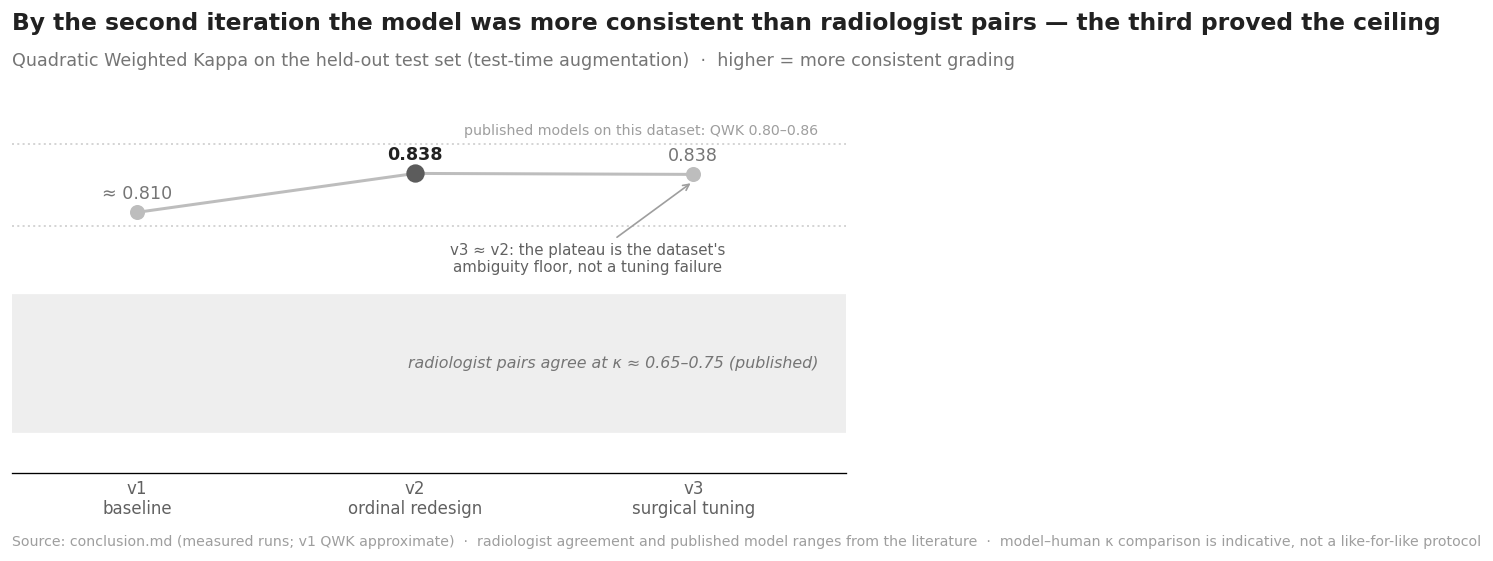

In [ ]:
# ── Figure B: model consistency vs human agreement ───────────────────────────
# QWK on the held-out test set (with test-time augmentation), from conclusion.md
VERSIONS = [
    ("v1", "baseline",          0.810),   # approximate
    ("v2", "ordinal redesign",  0.8383),
    ("v3", "surgical tuning",   0.8376),
]
RADIOLOGIST_LO, RADIOLOGIST_HI = 0.65, 0.75   # published inter-rater agreement
PUBLISHED_LO, PUBLISHED_HI     = 0.80, 0.86   # published model range on this dataset

xs   = list(range(len(VERSIONS)))
qwks = [q for _, _, q in VERSIONS]

fig, ax = plt.subplots(figsize=(11, 5))

# Human agreement band — the reference every bar is compared against
ax.axhspan(RADIOLOGIST_LO, RADIOLOGIST_HI, color="#EEEEEE", zorder=1)
ax.text(len(VERSIONS) - 0.55, (RADIOLOGIST_LO + RADIOLOGIST_HI) / 2,
        "radiologist pairs agree at κ ≈ 0.65–0.75 (published)",
        ha="right", va="center", fontsize=9.5, color="#757575", style="italic")

# Published model range as light reference lines
for y in (PUBLISHED_LO, PUBLISHED_HI):
    ax.axhline(y, color="#D5D5D5", linestyle=":", linewidth=1.2, zorder=1)
ax.text(len(VERSIONS) - 0.55, PUBLISHED_HI + 0.004,
        "published models on this dataset: QWK 0.80–0.86",
        ha="right", va="bottom", fontsize=8.5, color="#9E9E9E")

# The journey — v2 is the breakthrough, so it gets the dark emphasis
ax.plot(xs, qwks, color=GREY, linewidth=1.8, zorder=3)
for x, (v, name, q) in enumerate(VERSIONS):
    is_breakthrough = v == "v2"
    ax.plot(x, q, "o", markersize=10 if is_breakthrough else 8,
            color=ACCENT if is_breakthrough else GREY, zorder=4)
    approx = "≈ " if v == "v1" else ""
    ax.text(x, q + 0.007, f"{approx}{q:.3f}", ha="center", va="bottom",
            fontsize=10.5, fontweight="bold" if is_breakthrough else "normal",
            color=ACCENT_TEXT if is_breakthrough else "#757575")

ax.annotate("v3 ≈ v2: the plateau is the dataset's\nambiguity floor, not a tuning failure",
            xy=(2, 0.8376 - 0.005), xytext=(1.62, 0.788), fontsize=9,
            ha="center", va="top", color="#616161",
            arrowprops=dict(arrowstyle="->", color="#9E9E9E", lw=1.0))

ax.set_xticks(xs)
ax.set_xticklabels([f"{v}\n{name}" for v, name, _ in VERSIONS], fontsize=10, color="#616161")
ax.set_xlim(-0.45, len(VERSIONS) - 0.45)

# Headline = the takeaway
ax.text(0, 1.14, "By the second iteration the model was more consistent than radiologist "
                 "pairs — the third proved the ceiling",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.05, "Quadratic Weighted Kappa on the held-out test set (test-time augmentation)  ·  "
                 "higher = more consistent grading",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.16, "radiologist "
                  "agreement and published model ranges from the literature  ·  model–human κ "
                  "comparison is indicative, not a like-for-like protocol",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_ylim(0.62, 0.90)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Figure C — The Hardest Grade

Grade 1 is *defined* ambiguously ("doubtful joint narrowing, **possible** osteophytic lipping") —
it is where radiologists disagree most, and where the baseline model was barely better than random.
The ordinal redesign in v2 was aimed squarely at this boundary.

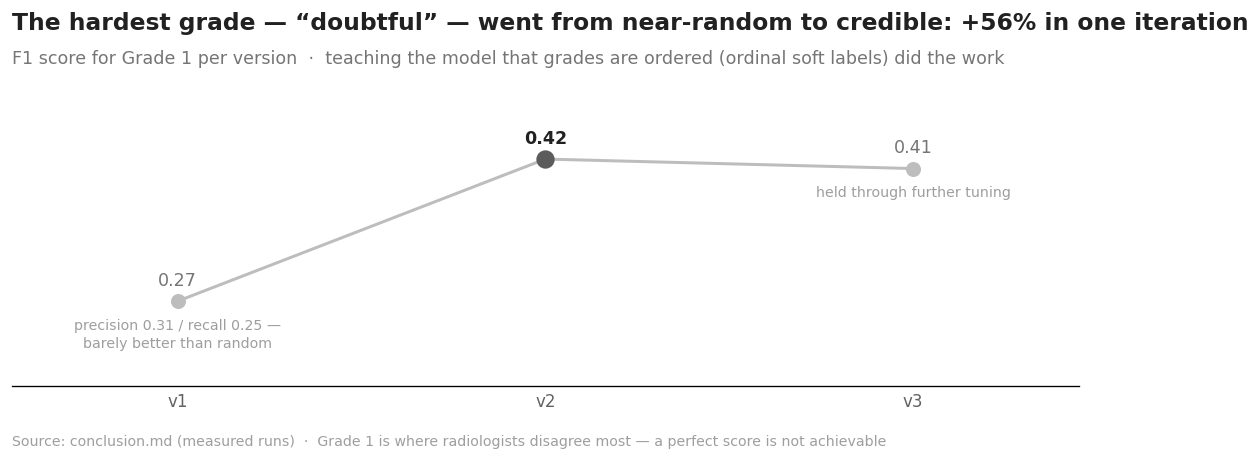

In [ ]:
# ── Figure C: Grade 1 — from near-random to credible ─────────────────────────
# F1 score for Grade 1 ("doubtful") per version, from conclusion.md
G1_F1 = [("v1", 0.27), ("v2", 0.42), ("v3", 0.41)]

xs   = list(range(len(G1_F1)))
f1s  = [f for _, f in G1_F1]
gain = 100 * (f1s[1] - f1s[0]) / f1s[0]

fig, ax = plt.subplots(figsize=(11, 4.2))

ax.plot(xs, f1s, color=GREY, linewidth=1.8, zorder=3)
for x, (v, f) in enumerate(G1_F1):
    is_jump = v == "v2"
    ax.plot(x, f, "o", markersize=10 if is_jump else 8,
            color=ACCENT if is_jump else GREY, zorder=4)
    ax.text(x, f + 0.012, f"{f:.2f}", ha="center", va="bottom", fontsize=10.5,
            fontweight="bold" if is_jump else "normal",
            color=ACCENT_TEXT if is_jump else "#757575")

ax.text(0, 0.27 - 0.018, "precision 0.31 / recall 0.25 —\nbarely better than random",
        ha="center", va="top", fontsize=8.5, color="#9E9E9E", linespacing=1.4)
ax.text(2, 0.41 - 0.018, "held through further tuning",
        ha="center", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_xticks(xs)
ax.set_xticklabels([v for v, _ in G1_F1], fontsize=10, color="#616161")
ax.set_xlim(-0.45, len(G1_F1) - 0.55)

ax.text(0, 1.16, f"The hardest grade — \u201cdoubtful\u201d — went from near-random to "
                 f"credible: +{gain:.0f}% in one iteration",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.05, "F1 score for Grade 1 per version  ·  teaching the model that grades are "
                 "ordered (ordinal soft labels) did the work",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.16, "Grade 1 is where radiologists "
                  "disagree most — a perfect score is not achievable",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_ylim(0.18, 0.50)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0)
plt.tight_layout()
plt.show()

### Figure D — What's Next: Better Inputs, Not More Tuning

The v2/v3 plateau showed that hyperparameter tuning is exhausted. The remaining levers all change
**what the model sees**, not how it trains — ranked by expected QWK gain (from `conclusion.md`).

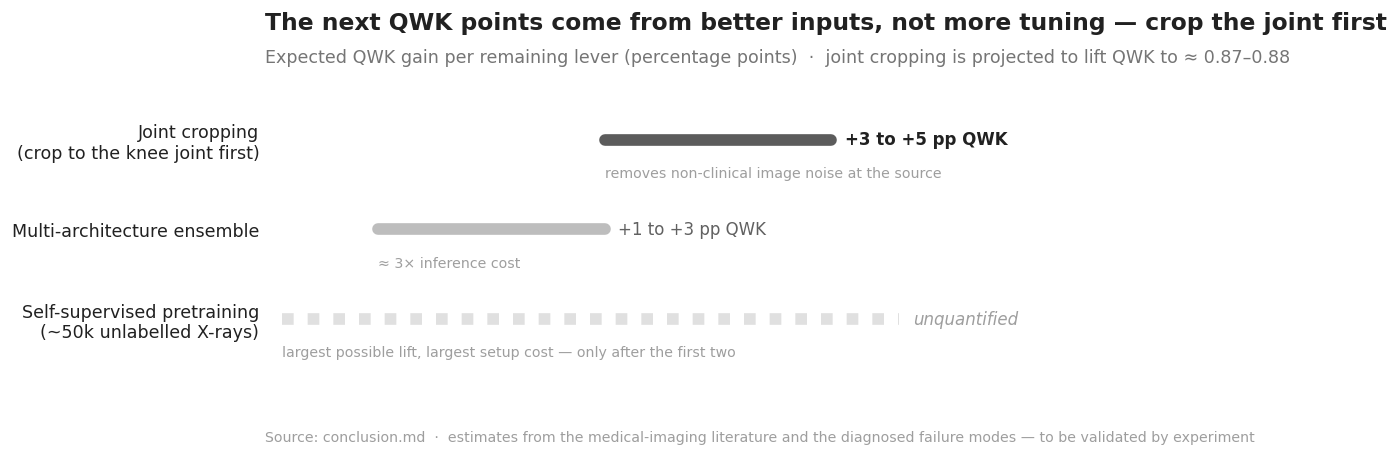

In [6]:
# ── Figure D: the remaining levers, ranked by expected gain ──────────────────
# Expected QWK gain in percentage points, from conclusion.md
LEVERS = [
    # (name, lo, hi, note, emphasised)
    ("Joint cropping\n(crop to the knee joint first)",  3.0, 5.0,
     "removes non-clinical image noise at the source", True),
    ("Multi-architecture ensemble",                      1.0, 3.0,
     "≈ 3× inference cost", False),
    ("Self-supervised pretraining\n(~50k unlabelled X-rays)", None, None,
     "largest possible lift, largest setup cost — only after the first two", False),
]

fig, ax = plt.subplots(figsize=(11, 4.2))

for i, (name, lo, hi, note, emphasised) in enumerate(reversed(LEVERS)):
    y = i
    color = ACCENT if emphasised else GREY
    if lo is not None:
        ax.plot([lo, hi], [y, y], color=color, linewidth=7, solid_capstyle="round", zorder=3)
        ax.text(hi + 0.12, y, f"+{lo:.0f} to +{hi:.0f} pp QWK",
                ha="left", va="center", fontsize=10,
                fontweight="bold" if emphasised else "normal",
                color=ACCENT_TEXT if emphasised else "#616161")
        ax.text(lo, y - 0.30, note, ha="left", va="top", fontsize=8.5, color="#9E9E9E")
    else:
        ax.plot([0.15, 5.6], [y, y], color=PALE, linewidth=7,
                solid_capstyle="round", linestyle=(0, (1, 1.2)), zorder=2)
        ax.text(5.72, y, "unquantified", ha="left", va="center",
                fontsize=10, color="#9E9E9E", style="italic")
        ax.text(0.15, y - 0.30, note, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_yticks(range(len(LEVERS)))
ax.set_yticklabels([name for name, *_ in reversed(LEVERS)], fontsize=10.5, color="#212121")

ax.text(0, 1.16, "The next QWK points come from better inputs, not more tuning — "
                 "crop the joint first",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=14, fontweight="bold", color="#212121")
ax.text(0, 1.05, "Expected QWK gain per remaining lever (percentage points)  ·  joint cropping "
                 "is projected to lift QWK to ≈ 0.87–0.88",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10.5, color="#757575")

ax.text(0, -0.18, "Source: conclusion.md  ·  estimates from the medical-imaging literature and "
                  "the diagnosed failure modes — to be validated by experiment",
        transform=ax.transAxes, ha="left", va="top", fontsize=8.5, color="#9E9E9E")

ax.set_xlim(0, 8.2)
ax.set_ylim(-0.65, len(LEVERS) - 0.35)
ax.set_xticks([])
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()